In [1]:
# Let's read the cleaned dataset to compute the exact statistics needed for Project 2
import pandas as pd
import numpy as np

filepath = 'Cleaned_Dataset_Data_Analytics.xlsx'
df = pd.read_excel(filepath)

# Basic Descriptive Statistics
desc_stats = df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].describe()
print("Descriptive Statistics:")
print(desc_stats.round(2))

# Skewness
print("\nSkewness:")
print(df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].skew())

# Pearson Correlation
print("\nPearson Correlation Matrix:")
print(df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].corr(method='pearson'))

Descriptive Statistics:
       Quantity  UnitPrice  TotalPrice  ItemsInCart
count   1200.00    1200.00     1200.00      1200.00
mean       2.95     356.41     1053.97         5.48
std        1.41     197.18      819.86         2.28
min        1.00      11.39       11.39         1.00
25%        2.00     186.06      410.52         4.00
50%        3.00     364.21      823.62         5.00
75%        4.00     521.57     1578.48         7.00
max        5.00     699.93     3456.40        10.00

Skewness:
Quantity       0.027922
UnitPrice     -0.026512
TotalPrice     0.891359
ItemsInCart    0.000877
dtype: float64

Pearson Correlation Matrix:
             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity     1.000000   0.014553    0.615251     0.650061
UnitPrice    0.014553   1.000000    0.717081     0.000602
TotalPrice   0.615251   0.717081    1.000000     0.392540
ItemsInCart  0.650061   0.000602    0.392540     1.000000


In [ ]:
# Calculate the exact IQR boundaries for TotalPrice to find outliers
q1 = df['TotalPrice'].quantile(0.25)
q3 = df['TotalPrice'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

outliers = df[df['TotalPrice'] > upper_bound]
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")
print(f"Number of outliers: {len(outliers)}")
print(outliers[['OrderID', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']])

Q1: 410.52, Q3: 1578.475, IQR: 1167.955
Upper Bound: 3330.4075, Lower Bound: -1341.4125
Number of outliers: 8
        OrderID CustomerID  Product  Quantity  UnitPrice  TotalPrice
107   ORD200107     C16775  Printer         5     670.75     3353.75
326   ORD200326     C65986   Laptop         5     670.48     3352.40
328   ORD200328     C18404   Tablet         5     674.04     3370.20
469   ORD200469     C13877    Chair         5     676.98     3384.90
632   ORD200632     C67260   Laptop         5     678.16     3390.80
789   ORD200789     C57276   Tablet         5     691.28     3456.40
1065  ORD201065     C47778  Printer         5     666.80     3334.00
1122  ORD201122     C38840  Monitor         5     678.19     3390.95


Saved plots to: eda_plots.png


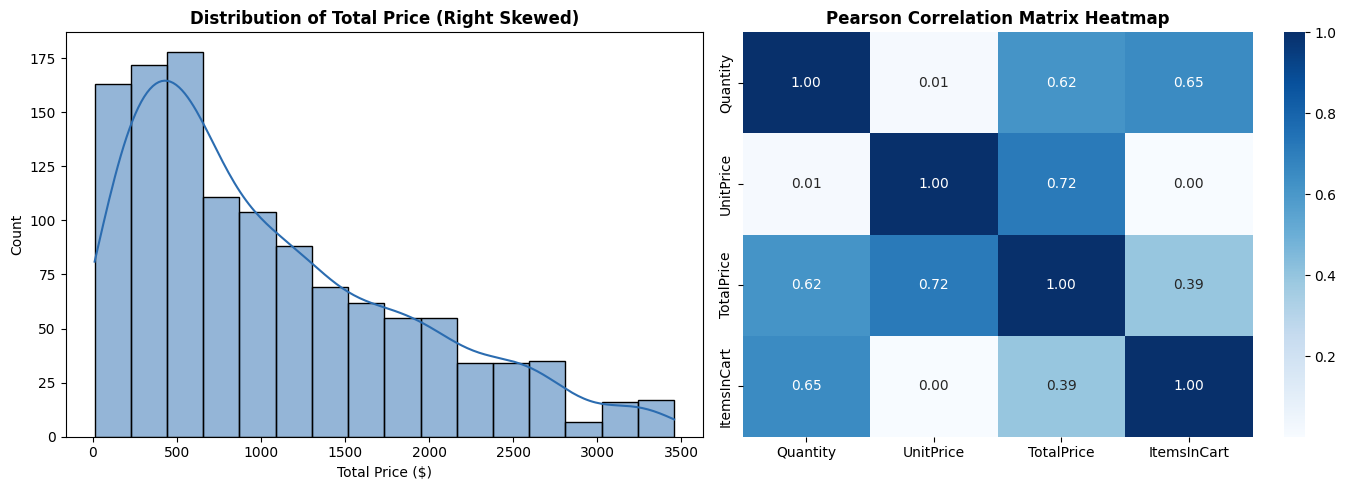

In [3]:
# Let's generate a beautiful correlation heatmap and distribution plot to present to stakeholders
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Total Price Distribution
sns.histplot(df['TotalPrice'], kde=True, ax=axes[0], color='#2b6cb0')
axes[0].set_title('Distribution of Total Price (Right Skewed)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Price ($)')
axes[0].set_ylabel('Count')

# 2. Correlation Matrix Heatmap
sns.heatmap(df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].corr(), annot=True, cmap='Blues', fmt='.2f', ax=axes[1])
axes[1].set_title('Pearson Correlation Matrix Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
eda_chart_path = 'eda_plots.png'
plt.savefig(eda_chart_path)
print("Saved plots to:", eda_chart_path)